1. Import Library

Digunakan untuk membaca data, visualisasi, preprocessing, modelling, dan evaluasi.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

2. Load Dataset

Tahap ini bertujuan melihat struktur awal dataset, memastikan data berhasil dibaca, dan memahami kolom-kolom yang tersedia.

In [3]:
df = pd.read_csv('chocolate_sales_2025_dataset.csv')
df.head()

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Cadbury,Milk Chocolate,France,Supermarket,Digital Wallet,5.00,194,970.00
1,2,2025-02-22,Lindt,Chocolate Bar,India,Online,Cash,17.73,144,2553.12
2,3,2025-02-17,Toblerone,Dark Chocolate,Australia,Supermarket,Digital Wallet,7.42,134,994.28
3,4,2025-11-29,Ferrero,Truffles,Italy,Convenience Store,Cash,18.28,112,2047.36
4,5,2025-03-23,Cadbury,Milk Chocolate,France,Convenience Store,Cash,18.21,92,1675.32


3. Data Understanding

Tahap ini digunakan untuk melihat tipe data, mengecek missing value dan memahami distribusi numerik

In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sale_ID         500 non-null    int64  
 1   Date            500 non-null    object 
 2   Brand           500 non-null    object 
 3   Product_Type    500 non-null    object 
 4   Country         500 non-null    object 
 5   Sales_Channel   500 non-null    object 
 6   Payment_Method  500 non-null    object 
 7   Price_USD       500 non-null    float64
 8   Units_Sold      500 non-null    int64  
 9   Revenue_USD     500 non-null    float64
dtypes: float64(2), int64(2), object(6)
memory usage: 39.2+ KB


Sale_ID           0
Date              0
Brand             0
Product_Type      0
Country           0
Sales_Channel     0
Payment_Method    0
Price_USD         0
Units_Sold        0
Revenue_USD       0
dtype: int64

Berdasarkan hasil eksplorasi awal, dataset memiliki 500 data transaksi dengan 10 variabel. Seluruh kolom memiliki data lengkap tanpa missing value sehingga dataset siap untuk tahap preprocessing dan modelling. Variabel terdiri dari kombinasi data kategorikal dan numerik yang relevan untuk analisis prediksi penjualan dan segmentasi customer.


4. Visualisasi Awal Data

Bertujuan untuk melihat apakah data revenue tersebar normal atau tidak.

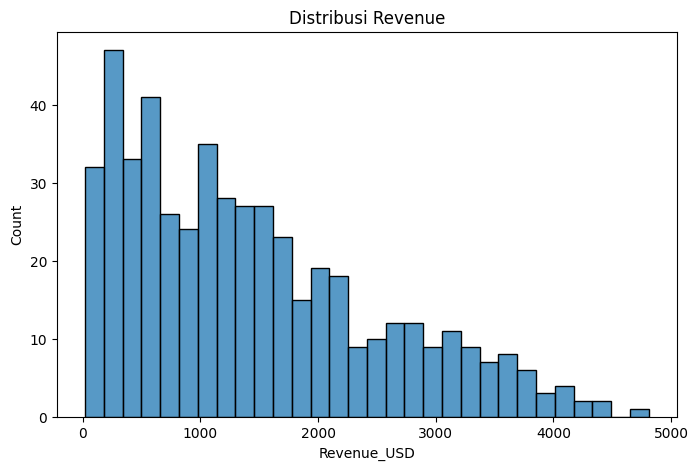

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['Revenue_USD'], bins=30)
plt.title('Distribusi Revenue')
plt.show()

Histogram distribusi revenue menunjukkan bahwa sebagian besar transaksi memiliki nilai revenue pada rentang rendah hingga menengah, sedangkan transaksi dengan revenue tinggi jumlahnya lebih sedikit. Pola ini menunjukkan distribusi data cenderung right-skewed, yaitu data lebih banyak terkonsentrasi di sisi kiri dengan ekor memanjang ke kanan. Kondisi ini umum ditemukan pada data penjualan karena hanya sebagian kecil transaksi yang menghasilkan revenue sangat tinggi.


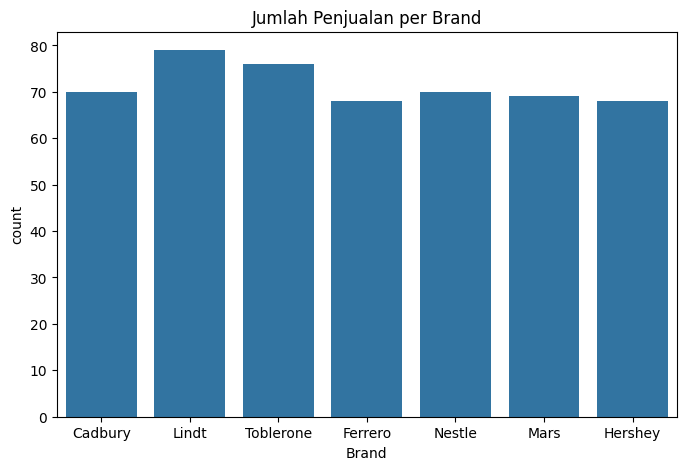

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Brand')
plt.title('Jumlah Penjualan per Brand')
plt.show()

Visualisasi jumlah penjualan per brand menunjukkan bahwa Lindt memiliki frekuensi transaksi tertinggi dibandingkan brand lainnya, diikuti oleh Toblerone. Meskipun demikian, selisih jumlah transaksi antar brand tidak terlalu besar sehingga distribusi data antar brand dapat dikatakan cukup seimbang. Kondisi ini menunjukkan bahwa dataset merepresentasikan berbagai brand secara merata dan mendukung proses analisis yang lebih objektif.

5. Data Processing

Tanggal dipecah menjadi bulan agar model bisa membaca pola musiman.

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month

Encoding Data Kategorikal

Ini karena model machine learning hanya bisa membaca angka, maka kategori diubah menjadi numerik.

In [8]:
le = LabelEncoder()

for col in ['Brand','Product_Type','Country','Sales_Channel','Payment_Method']:
    df[col] = le.fit_transform(df[col])

6. Feature Selection

In [9]:
X = df[['Brand','Product_Type','Country','Sales_Channel','Payment_Method','Price_USD','Units_Sold','Month']]
y = df['Revenue_USD']

Pada tahap feature selection, variabel Brand, Product_Type, Country, Sales_Channel, Payment_Method, Price_USD, Units_Sold, dan Month dipilih sebagai fitur input (X) untuk memprediksi Revenue_USD sebagai target output (y).

7. Split Data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Pada tahap split data, dataset dibagi menjadi 80% data training dan 20% data testing untuk melatih model serta menguji performanya pada data yang belum pernah dilihat sebelumnya.


8. Model Linear Regression

In [11]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

Pada tahap ini, model Linear Regression dibentuk dan dilatih menggunakan data training untuk mempelajari hubungan antara variabel input dengan target Revenue_USD. Output `LinearRegression()` menunjukkan bahwa model berhasil dibuat dan siap digunakan untuk melakukan prediksi pada data testing.


9. Prediksi

In [12]:
y_pred = model.predict(X_test)

Pada tahap prediksi, model Linear Regression digunakan untuk menghasilkan nilai prediksi Revenue_USD berdasarkan data testing yang telah dipisahkan sebelumnya. Hasil prediksi disimpan dalam variabel `y_pred` untuk kemudian dibandingkan dengan nilai aktual pada tahap evaluasi model.

10. Evaluasi Regression

In [13]:
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 299.8802806233118
RMSE: 404.0559850876104
R2 Score: 0.8680848253033026


Pada tahap evaluasi regression, digunakan tiga metrik yaitu MAE, RMSE, dan R² Score untuk mengukur seberapa baik model memprediksi Revenue_USD dibandingkan dengan nilai aktual. Hasil MAE sebesar 299.88 menunjukkan rata-rata selisih prediksi sekitar 299 USD, RMSE sebesar 404.06 menunjukkan masih ada beberapa error yang cukup besar, sedangkan nilai R² sebesar 0.868 berarti model mampu menjelaskan sekitar 86.8% variasi data sehingga performanya dapat dikategorikan baik.

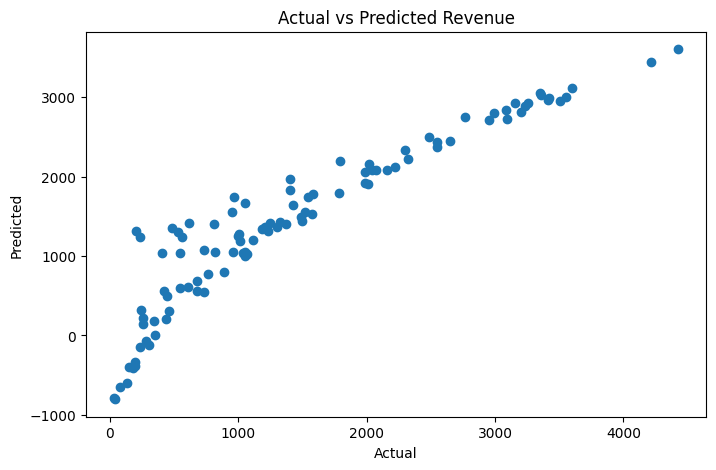

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Revenue")
plt.show()

Visualisasi Actual vs Predicted Revenue digunakan untuk membandingkan nilai revenue aktual dengan hasil prediksi model Linear Regression. Titik-titik yang membentuk pola naik dan relatif mendekati garis diagonal menunjukkan bahwa model mampu mengikuti pola data dengan cukup baik, meskipun masih terdapat beberapa prediksi yang menyimpang terutama pada nilai revenue rendah.

Secara keseluruhan, grafik ini mendukung hasil evaluasi sebelumnya bahwa model memiliki performa yang baik karena sebagian besar prediksi berada dekat dengan nilai aktual.

# CUSTOMER SEGMENTATION

In [15]:
cluster_data = df[['Price_USD','Units_Sold','Revenue_USD']]

Pada tahap ini dipilih tiga variabel numerik yaitu Price_USD, Units_Sold, dan Revenue_USD sebagai dasar clustering karena ketiganya merepresentasikan pola pembelian customer secara langsung.

In [16]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

Data kemudian dilakukan standardisasi menggunakan StandardScaler agar seluruh variabel memiliki skala yang seimbang, karena algoritma KMeans sensitif terhadap perbedaan rentang nilai antar fitur.

Menentukan Jumlah Cluster

Pada tahap ini digunakan metode Elbow Method untuk menentukan jumlah cluster yang paling optimal dengan cara menghitung nilai inertia pada beberapa jumlah cluster, mulai dari 1 sampai 10. Nilai inertia menunjukkan seberapa rapat data dalam satu cluster, sehingga semakin kecil nilainya berarti cluster semakin baik.

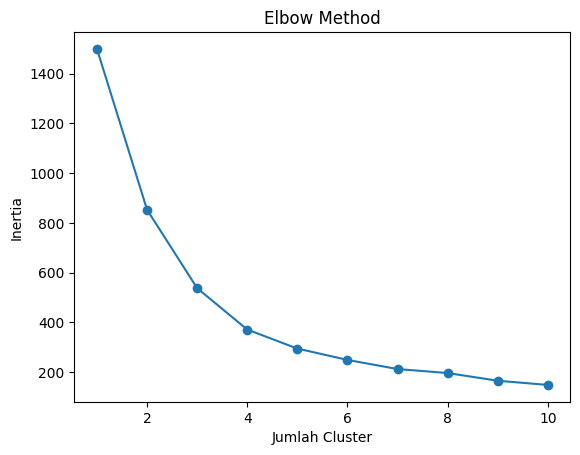

In [17]:
inertia = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.show()

Berdasarkan grafik Elbow Method, penurunan inertia terlihat sangat tajam dari cluster 1 hingga cluster 3, kemudian mulai melandai setelahnya. Titik siku (elbow) terlihat pada sekitar 3 cluster, sehingga jumlah cluster optimal yang dipilih adalah 3 karena setelah titik tersebut penurunan inertia tidak lagi signifikan.

##### KMeans Clustering

In [18]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

Pada tahap ini, algoritma KMeans dijalankan dengan jumlah cluster sebanyak 3 sesuai hasil Elbow Method, kemudian setiap data dikelompokkan ke dalam cluster tertentu dan hasilnya disimpan pada kolom `Cluster`. Proses ini bertujuan untuk membagi customer berdasarkan kemiripan pola pembelian dilihat dari Price_USD, Units_Sold, dan Revenue_USD.

##### Evaluasi Clustering

In [19]:
score = silhouette_score(scaled_data, df['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.3998760134564226


Evaluasi clustering dilakukan menggunakan Silhouette Score untuk mengukur seberapa baik pemisahan antar cluster yang terbentuk. Nilai silhouette score sebesar 0.3999 menunjukkan bahwa kualitas cluster cukup baik, karena data dalam satu cluster cukup mirip meskipun masih terdapat sedikit overlap antar cluster.

### Visualisasi Cluster

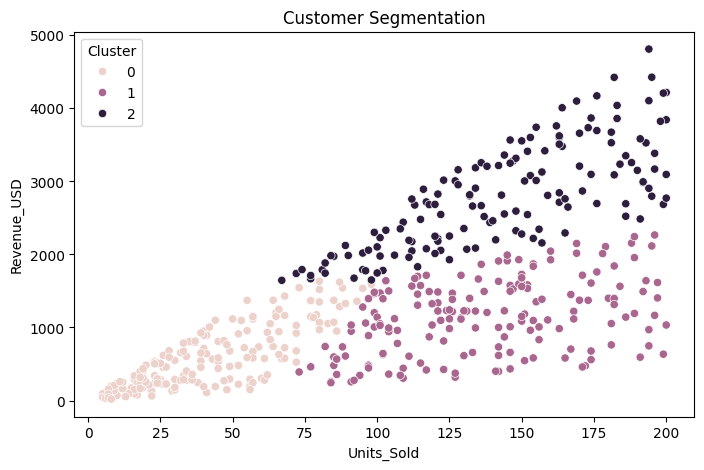

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Units_Sold', y='Revenue_USD', hue='Cluster', data=df)
plt.title('Customer Segmentation')
plt.show()

Visualisasi scatter plot menunjukkan hasil segmentasi customer ke dalam tiga cluster berdasarkan hubungan antara Units_Sold dan Revenue_USD. Cluster 0 terlihat berada pada area penjualan rendah dengan revenue rendah, cluster 1 berada pada tingkat menengah, sedangkan cluster 2 mendominasi area dengan jumlah unit terjual dan revenue tertinggi sehingga dapat diartikan sebagai kelompok customer bernilai tinggi. Grafik ini menunjukkan bahwa hasil clustering berhasil memisahkan customer berdasarkan karakteristik pembelian, sehingga dapat digunakan untuk mendukung strategi segmentasi pasar.

##### Rata-rata Nilai Setiap Cluster

In [21]:
df.groupby('Cluster')[['Revenue_USD','Units_Sold','Price_USD']].mean()

,Revenue_USD,Units_Sold,Price_USD
Cluster,,,
0,587.278814,41.627119,14.043842
1,1146.080341,136.886364,8.446932
2,2796.170612,142.918367,19.847007


Tabel ini menunjukkan rata-rata nilai Revenue_USD, Units_Sold, dan Price_USD pada setiap cluster untuk memahami karakteristik masing-masing kelompok customer. Cluster 0 memiliki nilai pembelian paling rendah, cluster 1 menunjukkan jumlah unit terjual tinggi namun dengan harga produk lebih rendah, sedangkan cluster 2 memiliki revenue tertinggi sehingga dapat dikategorikan sebagai kelompok high-value customer.